# Tugas Praktikum 1 — Scraping & Eksplorasi Data (EDA)

| | |
|---|---|
| **Nama** | Muhammad Rafie Safaraz Barus |
| **NRP** | 50542510114 |
| **Mata kuliah** | Data Mining |



**Alur notebook:** 1) Scraping → 2) EDA → 3) Preproces →
4) Visualisasi  → 5) Ringkasan laporan.

## 1. Scraping Dataset

Sumber data: halaman detail produk di nilaigizi.com (`/gizi/detailproduk/{id}`). Hasil scraping mentah disimpan ke `data/nilaigizi_raw.csv` supaya scraping tidak perlu diulang.

In [1]:
import re
import time
from pathlib import Path
from urllib.parse import urljoin
from urllib.robotparser import RobotFileParser

import pandas as pd
import requests
from bs4 import BeautifulSoup

BASE_URL = "https://nilaigizi.com/gizi/detailproduk/{}"
USER_AGENT = "DM-Praktikum-Scraper/1.0 (tugas kuliah Data Mining; edukasi)"
REQUEST_TIMEOUT_SECONDS = 20
JEDA_DETIK = 0.5        # jeda antar request supaya tidak membebani server
MAKS_PERCOBAAN = 3      # berapa kali request diulang kalau gagal
TARGET_BARIS = 1800     # berhenti setelah dapat 1800 halaman berisi data
ID_MAKS = 8000          # batas atas ID yang dicoba
RAW_PATH = Path("data") / "nilaigizi_raw.csv"

In [2]:
def diizinkan_robots(url):
    try:
        respons = requests.get(urljoin(url, "/robots.txt"), headers={"User-Agent": USER_AGENT},
                               timeout=REQUEST_TIMEOUT_SECONDS)
    except requests.RequestException:
        return False  # tidak bisa memastikan, jadi jangan scraping
    if 400 <= respons.status_code < 500:
        return True   # tidak ada robots.txt berarti tidak ada larangan
    if not respons.ok:
        return False

    parser = RobotFileParser()
    parser.parse(respons.text.splitlines())
    return parser.can_fetch(USER_AGENT, url)


def ambil_html(sesi, url):
    """Mengunduh halaman. Kalau gagal, dicoba ulang sampai MAKS_PERCOBAAN kali."""
    for percobaan in range(1, MAKS_PERCOBAAN + 1):
        try:
            respons = sesi.get(url, timeout=REQUEST_TIMEOUT_SECONDS)
            respons.raise_for_status()
            return respons.text
        except requests.RequestException:
            if percobaan == MAKS_PERCOBAAN:
                raise
            time.sleep(2 * percobaan)  # tunggu 2 detik, lalu 4 detik

In [3]:
def parse_detail(id_produk, html):
    soup = BeautifulSoup(html, "html.parser")
    nama = soup.select_one("span.h5 b")
    label = soup.select_one("div.card-body span.m-0")
    tabel = soup.select_one("table")
    if nama is None or label is None or tabel is None:
        return None  # ID sudah dihapus -> server mengalihkan ke halaman /gizi

    kontributor = label.find("span", class_="float-right")
    if kontributor is not None:
        kontributor.decompose()  # nama kontributor (data pribadi) tidak disimpan

    basis = soup.find("h8")
    bdd = soup.find(string=re.compile(r"Berat Dapat Dimakan \(\d+%\)"))
    data = {
        "id": id_produk,
        "label": label.get_text(" ", strip=True),
        "nama": nama.get_text(strip=True),
        "basis": basis.get_text(strip=True) if basis else None,
        "bdd": bdd.strip() if bdd else None,
    }

    # tiap baris tabel gizi menjadi satu kolom, misalnya data["Energi"] = "180 kkal"
    for tr in tabel.select("tr"):
        sel = [td.get_text(" ", strip=True) for td in tr.select("td, th")]
        if len(sel) < 2 or not sel[0] or sel[0] in data:
            continue
        data[sel[0]] = sel[-1] if sel[0] == "Jumlah Sajian Per Kemasan" else sel[1]
    return data

Uji parser pada satu halaman (*Nasi putih*, ID 22):

In [4]:
with requests.Session() as sesi:
    sesi.headers["User-Agent"] = USER_AGENT
    contoh = parse_detail(22, ambil_html(sesi, BASE_URL.format(22)))

pd.Series(contoh).head(12)

id                                              22
label                                        Alami
nama                             Nasi / Nasi Putih
basis          Per 100 g BDD (Berat Dapat Dimakan)
bdd                     Berat Dapat Dimakan (100%)
Energi                                    180 kkal
Lemak total                                 0.30 g
Vitamin A                                    0 mcg
Vitamin B1                                 0.05 mg
Vitamin B2                                 0.10 mg
Vitamin B3                                 2.60 mg
Vitamin C                                     0 mg
dtype: object

In [5]:
# Kalau file mentah sudah ada, scraping dilewati. Hapus file-nya untuk scraping ulang.
if RAW_PATH.exists():
    print(f"{RAW_PATH} sudah ada, scraping dilewati.")
else:
    if not diizinkan_robots(BASE_URL.format(1)):
        raise PermissionError("robots.txt tidak mengizinkan halaman ini di-scrape")

    hasil = []
    with requests.Session() as sesi:
        sesi.headers["User-Agent"] = USER_AGENT
        for id_produk in range(1, ID_MAKS + 1):
            if len(hasil) >= TARGET_BARIS:
                break
            try:
                html = ambil_html(sesi, BASE_URL.format(id_produk))
            except requests.RequestException as error:
                print(f"ID {id_produk} gagal diambil: {error}")
                continue

            data = parse_detail(id_produk, html)
            if data is not None:  # None = halaman kosong (ID sudah dihapus)
                hasil.append(data)
            if id_produk % 100 == 0:
                print(f"ID {id_produk}: {len(hasil)} baris valid")
            time.sleep(JEDA_DETIK)

    RAW_PATH.parent.mkdir(exist_ok=True)
    pd.DataFrame(hasil).to_csv(RAW_PATH, index=False)
    print(f"Selesai: {len(hasil)} baris (dari ID 1-{id_produk}) disimpan ke {RAW_PATH}")

data\nilaigizi_raw.csv sudah ada, scraping dilewati.


## 2. EDA

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", 60)

In [7]:
def tentukan_jenis_sumber(label):
    if label == "Alami":
        return "Bahan alami"
    if label.startswith("Buatan Sendiri"):
        return "Buatan sendiri"
    if re.search(r"\b(PT|CV|UD|Tbk|Koperasi)\b", label, flags=re.IGNORECASE):
        return "Produk industri"
    return "Merek/restoran"


def ambil_angka(seri):
    """'1.70 g' -> 1.7"""
    return seri.str.extract(r"(\d+(?:[.,]\d+)?)", expand=False).str.replace(",", ".").astype(float)


def ambil_satuan(seri):
    """'1.70 g' -> 'g', '(14 g)' -> 'g'"""
    return seri.str.extract(r"\d+(?:[.,]\d+)?\s*([^\d\s]*)", expand=False).str.strip("()")


# semua kolom dibaca sebagai teks dulu, misalnya "180 kkal"
df_raw = pd.read_csv(RAW_PATH, dtype=str)
per_100g = df_raw["basis"].str.contains("100 g", na=False)  # data TKPI: nilai per 100 g

# kolom informasi produk
KOLOM_INFO = ["id", "nama", "jenis_sumber", "produsen", "satuan_saji",
              "takaran_saji", "sajian_per_kemasan", "bdd_persen"]
df = pd.DataFrame({"id": df_raw["id"].astype(int), "nama": df_raw["nama"]})
df["jenis_sumber"] = df_raw["label"].map(tentukan_jenis_sumber)
df["produsen"] = df_raw["label"].where(df["jenis_sumber"].isin(["Produk industri", "Merek/restoran"]))
df["satuan_saji"] = ambil_satuan(df_raw["Jumlah Per Sajian"]).replace("gram", "g").mask(per_100g, "g")
df["takaran_saji"] = ambil_angka(df_raw["Jumlah Per Sajian"]).mask(per_100g, 100.0)
df["sajian_per_kemasan"] = ambil_angka(df_raw["Jumlah Sajian Per Kemasan"])
df["bdd_persen"] = ambil_angka(df_raw["bdd"])

# kolom zat gizi: teks jadi angka, nama kolom = nama zat + satuan (misal energi_kkal)
zat_gizi = {}
for kolom in df_raw.columns[5:]:  # 5 kolom pertama = info produk, sisanya baris tabel gizi
    if kolom in ("Jumlah Per Sajian", "Jumlah Sajian Per Kemasan"):
        continue
    nama_kolom = re.sub(r"[^a-z0-9]+", "_", kolom.lower()).strip("_")
    satuan = ambil_satuan(df_raw[kolom])
    satuan = satuan[satuan != ""].mode()  # satuan yang paling sering muncul
    if len(satuan) > 0:
        nama_kolom += "_" + satuan[0]
    zat_gizi[nama_kolom] = ambil_angka(df_raw[kolom])

df_gizi = pd.DataFrame(zat_gizi)
urutan_gizi = df_gizi.notna().sum().sort_values(ascending=False).index  # yang paling lengkap di depan
df = pd.concat([df, df_gizi[urutan_gizi]], axis=1)

In [8]:
display(df.head())
print("Shape :", df.shape)
df.info()
df.dtypes.value_counts()

,id,nama,jenis_sumber,produsen,satuan_saji,takaran_saji,sajian_per_kemasan,bdd_persen,energi_kkal,lemak_total_g,karbohidrat_total_g,protein_g,natrium_mg,serat_pangan_g,kalsium_mg,besi_mg,vitamin_a_mcg,vitamin_c_mg,kalium_mg,vitamin_b1_mg,vitamin_b2_mg,seng_mg,air_g,fosfor_mg,tembaga_mcg,vitamin_b3_mg,b_karoten_mcg,abu_g,gula_g,kolesterol_mg,lemak_jenuh_g,energi_dari_lemak_kkal,lemak_trans_g,vitamin_e_mg,lemak_tidak_jenuh_ganda_g,energi_dari_lemak_jenuh_kkal,folat_mcg,vitamin_b6_mg,magnesium_mg,karoten_total
0,1,"Beras giling, mentah",Bahan alami,NaN,g,100.0,NaN,100.0,357.0,1.7,77.1,8.4,27.0,0.2,147.0,1.8,0.0,0.0,71.0,0.20,0.08,0.5,12.0,81.0,100.0,2.6,0.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,"Beras giling var pelita,mentah",Bahan alami,NaN,g,100.0,NaN,100.0,369.0,1.4,77.1,9.5,34.0,0.4,68.0,1.4,0.0,0.0,0.0,0.26,0.00,0.0,11.4,171.0,0.0,0.0,0.0,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,"Beras giling var rojolele, mentah",Bahan alami,NaN,g,100.0,NaN,100.0,357.0,1.7,77.1,8.4,34.0,0.2,147.0,1.8,0.0,0.0,112.9,0.20,0.02,0.1,12.0,81.0,140.0,1.5,0.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,"Beras hitam, mentah",Bahan alami,NaN,g,100.0,NaN,100.0,351.0,1.3,76.9,8.0,15.0,20.1,6.0,0.1,0.0,0.0,105.0,0.21,0.06,1.6,12.9,198.0,100.0,0.0,0.0,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,"Beras jagung kuning kering, mentah",Bahan alami,NaN,g,100.0,NaN,100.0,358.0,0.1,82.7,5.5,1.0,10.0,20.0,1.4,0.0,3.0,80.0,0.12,0.08,4.1,10.8,90.0,1100.0,1.0,641.0,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape : (1800, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            1800 non-null   int64  
 1   nama                          1800 non-null   object 
 2   jenis_sumber                  1800 non-null   object 
 3   produsen                      577 non-null    object 
 4   satuan_saji                   1796 non-null   object 
 5   takaran_saji                  1796 non-null   float64
 6   sajian_per_kemasan            616 non-null    float64
 7   bdd_persen                    991 non-null    float64
 8   energi_kkal                   1800 non-null   float64
 9   lemak_total_g                 1800 non-null   float64
 10  karbohidrat_total_g           1800 non-null   float64
 11  protein_g                     1800 non-null   float64
 12  natrium_mg                    1773 non-null

float64    35
object      4
int64       1
Name: count, dtype: int64

In [9]:
tipe_atribut = pd.DataFrame([
    ("id", "Nominal (identifier)", "Nomor unik halaman; angkanya tidak bermakna untuk dihitung"),
    ("nama", "Nominal", "Nama makanan, tidak memiliki urutan"),
    ("jenis_sumber", "Nominal", "Bahan alami / Produk industri / Merek-restoran / Buatan sendiri, tanpa urutan"),
    ("produsen", "Nominal", "Nama perusahaan atau merek"),
    ("satuan_saji", "Nominal", "Satuan takaran saji: g atau ml"),
    ("takaran_saji", "Numerik kontinu (rasio)", "Berat/volume satu sajian; punya nol mutlak"),
    ("sajian_per_kemasan", "Numerik diskrit", "Banyaknya sajian dalam satu kemasan (hasil menghitung)"),
    ("bdd_persen", "Numerik diskrit (rasio)", "Persen bagian yang dapat dimakan, bilangan bulat 0-100"),
    (f"{df.shape[1] - len(KOLOM_INFO)} kolom zat gizi", "Numerik kontinu (rasio)", "Kandungan zat gizi hasil pengukuran; punya nol mutlak"),
], columns=["atribut", "tipe", "alasan"])
tipe_atribut.style.hide(axis="index")

atribut,tipe,alasan
id,Nominal (identifier),Nomor unik halaman; angkanya tidak bermakna untuk dihitung
nama,Nominal,"Nama makanan, tidak memiliki urutan"
jenis_sumber,Nominal,"Bahan alami / Produk industri / Merek-restoran / Buatan sendiri, tanpa urutan"
produsen,Nominal,Nama perusahaan atau merek
satuan_saji,Nominal,Satuan takaran saji: g atau ml
takaran_saji,Numerik kontinu (rasio),Berat/volume satu sajian; punya nol mutlak
sajian_per_kemasan,Numerik diskrit,Banyaknya sajian dalam satu kemasan (hasil menghitung)
bdd_persen,Numerik diskrit (rasio),"Persen bagian yang dapat dimakan, bilangan bulat 0-100"
32 kolom zat gizi,Numerik kontinu (rasio),Kandungan zat gizi hasil pengukuran; punya nol mutlak


In [10]:
ZAT_UTAMA = {
    "energi_kkal": "Energi (kkal)",
    "protein_g": "Protein (g)",
    "lemak_total_g": "Lemak total (g)",
    "karbohidrat_total_g": "Karbohidrat (g)",
    "serat_pangan_g": "Serat pangan (g)",
    "gula_g": "Gula (g)",
    "natrium_mg": "Natrium (mg)",
}

# takaran saji 0 pasti salah input, dianggap tidak diketahui supaya tidak dibagi nol
print("Baris dengan takaran saji = 0:", (df["takaran_saji"] == 0).sum())
takaran = df["takaran_saji"].where(df["takaran_saji"] > 0)

# samakan semua nilai menjadi per 100 g (minuman diasumsikan 1 ml = 1 g)
faktor_100g = 100 / takaran
for kolom in ZAT_UTAMA:
    df[kolom + "_100g"] = df[kolom] * faktor_100g

KOLOM_100G = [kolom + "_100g" for kolom in ZAT_UTAMA]
LABEL = {kolom + "_100g": label for kolom, label in ZAT_UTAMA.items()}

# atribut ordinal turunan: kepadatan energi (kkal per 100 g)
URUTAN_ENERGI = ["Sangat rendah", "Rendah", "Sedang", "Tinggi"]
df["kategori_energi"] = pd.cut(df["energi_kkal_100g"], bins=[0, 60, 150, 400, np.inf],
                               labels=URUTAN_ENERGI, right=False, ordered=True)
df[["nama", "jenis_sumber", "takaran_saji", "satuan_saji", "energi_kkal", "energi_kkal_100g", "kategori_energi"]].sample(5, random_state=1)

Baris dengan takaran saji = 0: 69


,nama,jenis_sumber,takaran_saji,satuan_saji,energi_kkal,energi_kkal_100g,kategori_energi
1462,Selai Smucker's Strawberry,Produk industri,20.0,g,50.0,250.000000,Sedang
510,Mostarda metan-sawi,Bahan alami,100.0,g,33.0,33.000000,Sangat rendah
612,"Apel, segar",Bahan alami,100.0,g,58.0,58.000000,Sangat rendah
1322,Frisian flag coconut delight,Produk industri,225.0,ml,160.0,71.111111,Rendah
993,"Udang papay, mentah",Bahan alami,100.0,g,273.0,273.000000,Sedang


## 3. Preprocessing

In [11]:
KOLOM_NUMERIK = KOLOM_100G + ["takaran_saji", "sajian_per_kemasan", "bdd_persen"]


def statistik_deskriptif(data):
    return pd.DataFrame({
        "n": data.count(),
        "rata_rata": data.mean(),
        "median": data.median(),
        "modus": data.mode().iloc[0],
        "std": data.std(),
        "min": data.min(),
        "maks": data.max(),
    }).round(2)


statistik_deskriptif(df[KOLOM_NUMERIK])

,n,rata_rata,median,modus,std,min,maks
energi_kkal_100g,1727,233.17,180.0,0.0,222.60,0.0,6000.0
protein_g_100g,1727,9.24,5.4,0.0,10.72,0.0,80.0
lemak_total_g_100g,1727,9.18,3.2,0.0,14.36,0.0,150.0
karbohidrat_total_g_100g,1727,28.98,17.6,0.0,36.44,0.0,1050.0
serat_pangan_g_100g,1441,2.68,1.2,0.0,5.02,0.0,100.0
gula_g_100g,402,17.54,9.0,0.0,36.32,0.0,650.0
natrium_mg_100g,1700,133.94,2.0,0.0,538.34,0.0,11998.0
takaran_saji,1796,99.98,100.0,100.0,75.45,0.0,903.0
sajian_per_kemasan,616,2.66,1.0,1.0,7.28,0.0,50.0
bdd_persen,991,90.63,100.0,100.0,16.31,20.0,100.0


In [12]:
def tabel_frekuensi(frek):
    return pd.DataFrame({"frekuensi": frek, "persen": (frek / frek.sum() * 100).round(2)})


display(tabel_frekuensi(df["jenis_sumber"].value_counts()))
display(tabel_frekuensi(df["satuan_saji"].value_counts()))
display(tabel_frekuensi(df["kategori_energi"].value_counts().reindex(URUTAN_ENERGI)))  # ordinal: urut rendah ke tinggi

,frekuensi,persen
jenis_sumber,,
Bahan alami,1184,65.78
Produk industri,366,20.33
Merek/restoran,211,11.72
Buatan sendiri,39,2.17


,frekuensi,persen
satuan_saji,,
g,1685,93.82
ml,111,6.18


,frekuensi,persen
kategori_energi,,
Sangat rendah,306,17.72
Rendah,464,26.87
Sedang,637,36.88
Tinggi,320,18.53


In [13]:
nilai_hilang = pd.DataFrame({"jumlah_hilang": df.isna().sum(), "persen": (df.isna().mean() * 100).round(2)})
display(nilai_hilang[nilai_hilang["jumlah_hilang"] > 0].sort_values("persen", ascending=False))

# apakah hilangnya merata? cek persen kosong per jenis sumber
(df[list(ZAT_UTAMA) + ["takaran_saji"]].isna().groupby(df["jenis_sumber"]).mean() * 100).round(1)

,jumlah_hilang,persen
karoten_total,1800,100.00
magnesium_mg,1799,99.94
vitamin_b6_mg,1799,99.94
energi_dari_lemak_jenuh_kkal,1799,99.94
vitamin_e_mg,1799,99.94
lemak_tidak_jenuh_ganda_g,1799,99.94
folat_mcg,1799,99.94
lemak_trans_g,1798,99.89
energi_dari_lemak_kkal,1782,99.00
lemak_jenuh_g,1777,98.72


,energi_kkal,protein_g,lemak_total_g,karbohidrat_total_g,serat_pangan_g,gula_g,natrium_mg,takaran_saji
jenis_sumber,,,,,,,,
Bahan alami,0.0,0.0,0.0,0.0,1.4,100.0,2.3,0.0
Buatan sendiri,0.0,0.0,0.0,0.0,69.2,53.8,0.0,0.0
Merek/restoran,0.0,0.0,0.0,0.0,39.8,29.9,0.0,0.5
Produk industri,0.0,0.0,0.0,0.0,52.5,23.0,0.0,0.8


In [14]:
# natrium 0 mg wajar untuk bahan alami, tapi mencurigakan untuk produk kemasan
natrium_nol = (df["natrium_mg"] == 0).groupby(df["jenis_sumber"]).mean() * 100
print("Persentase natrium tercatat 0 mg per jenis sumber:")
print(natrium_nol.round(1).to_string())
df[(df["jenis_sumber"] != "Bahan alami") & (df["natrium_mg"] == 0)][
    ["nama", "produsen", "takaran_saji", "energi_kkal", "natrium_mg"]].head(8)

Persentase natrium tercatat 0 mg per jenis sumber:
jenis_sumber
Bahan alami        25.4
Buatan sendiri     87.2
Merek/restoran     88.6
Produk industri    84.4


,nama,produsen,takaran_saji,energi_kkal,natrium_mg
1161,Permen KIS mini assorted,PT. Mayora Indah Tbk.,7.5,30.0,0.0
1163,Butter cookies Monde,PT. nissin biscuit indonesia,30.0,160.0,0.0
1172,lontong,NaN,90.0,144.0,0.0
1186,Indomie goreng Jumbo,PT. Indofood CBP Sukses Makmur Tbk.,129.0,560.0,0.0
1187,Indomie goreng,PT. Indofood CBP Sukses Makmur Tbk.,300.0,380.0,0.0
1188,Indomie mi kuah,PT. Indofood CBP Sukses Makmur Tbk.,69.0,300.0,0.0
1189,Samyang,Samyang Foods Co.Ltd Korea,140.0,530.0,0.0
1190,Mie sedap goreng,PT.Wings food,91.0,420.0,0.0


In [15]:
# outlier dengan aturan IQR: di luar Q1 - 1.5*IQR sampai Q3 + 1.5*IQR
hasil = {}
for kolom in KOLOM_100G:
    seri = df[kolom].dropna()
    q1, q3 = seri.quantile([0.25, 0.75])
    iqr = q3 - q1
    bawah, atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    jumlah = ((seri < bawah) | (seri > atas)).sum()
    hasil[kolom] = {"Q1": q1, "Q3": q3, "IQR": iqr, "batas_bawah": bawah, "batas_atas": atas,
                    "jumlah_outlier": jumlah, "persen": 100 * jumlah / len(seri)}
pd.DataFrame(hasil).T.round(2)

,Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_outlier,persen
energi_kkal_100g,80.00,357.00,277.00,-335.50,772.50,11.0,0.64
protein_g_100g,1.86,13.00,11.14,-14.85,29.71,94.0,5.44
lemak_total_g_100g,0.50,12.72,12.22,-17.83,31.05,120.0,6.95
karbohidrat_total_g_100g,6.07,52.50,46.43,-63.58,122.14,1.0,0.06
serat_pangan_g_100g,0.00,3.40,3.40,-5.10,8.50,102.0,7.08
gula_g_100g,3.69,21.06,17.37,-22.38,47.12,40.0,9.95
natrium_mg_100g,0.00,51.00,51.00,-76.50,127.50,292.0,17.18


In [16]:
# outlier energi tertinggi: salah data atau memang wajar?
df.nlargest(8, "energi_kkal_100g")[["nama", "jenis_sumber", "takaran_saji", "energi_kkal",
                                    "energi_kkal_100g", "lemak_total_g_100g"]]

,nama,jenis_sumber,takaran_saji,energi_kkal,energi_kkal_100g,lemak_total_g_100g
1798,Maxtea tarik,Produk industri,2.0,120.0,6000.0,150.0
1074,Lemak babi (lard),Bahan alami,100.0,902.0,902.0,100.0
1078,Minyak hati hiu,Bahan alami,100.0,902.0,902.0,100.0
1079,Minyak ikan,Bahan alami,100.0,902.0,902.0,100.0
1080,Minyak kacang tanah,Bahan alami,100.0,902.0,902.0,100.0
1083,Minyak goreng kelapa sawit,Bahan alami,100.0,884.0,884.0,100.0
1085,Minyak zaitun,Bahan alami,100.0,884.0,884.0,100.0
1081,Minyak kedele,Bahan alami,100.0,883.0,883.0,99.9


In [17]:
def nilai_mustahil(data):
    """Energi > 910 kkal atau protein+lemak+karbohidrat > 105 g per 100 g tidak mungkin secara fisik."""
    makro = data[["protein_g_100g", "lemak_total_g_100g", "karbohidrat_total_g_100g"]].sum(axis=1, min_count=1)
    return (data["energi_kkal_100g"] > 910) | (makro > 105)


mustahil = nilai_mustahil(df)
print("Baris dengan nilai per 100 g yang mustahil:", mustahil.sum())
df.loc[mustahil, ["nama", "jenis_sumber", "takaran_saji", "energi_kkal", "energi_kkal_100g",
                  "protein_g_100g", "lemak_total_g_100g", "karbohidrat_total_g_100g"]].head(8)

Baris dengan nilai per 100 g yang mustahil: 10


,nama,jenis_sumber,takaran_saji,energi_kkal,energi_kkal_100g,protein_g_100g,lemak_total_g_100g,karbohidrat_total_g_100g
963,"Ikan Dendeng mujahir, mentah",Bahan alami,100.0,582.0,582.000000,68.300000,15.200000,37.200000
1001,"Dendeng mujahir goreng, masakan",Bahan alami,100.0,598.0,598.000000,74.300000,26.900000,9.200000
1146,Milo Activ-Go 18 gram,Produk industri,14.0,80.0,571.428571,14.285714,14.285714,92.857143
1150,Frisian Flag kental manis kemasan ekonomis 560...,Produk industri,40.0,140.0,350.000000,2.500000,100.000000,57.500000
1615,Granola Bites chocolate vanilla,Produk industri,30.0,159.0,530.000000,10.000000,26.666667,70.000000
1654,Sariroti roti krim cokelat,Produk industri,60.0,220.0,366.666667,6.666667,13.333333,86.666667
1666,Kewpie Vanila Stroberi,Merek/restoran,15.0,90.0,600.000000,40.000000,40.000000,60.000000
1759,Tropinana Slim Stevia,Produk industri,2.6,0.0,0.000000,0.000000,0.000000,115.384615


In [18]:
df_bersih = df.copy()
df_bersih["produsen"] = df_bersih["produsen"].fillna("(tanpa produsen)")

# 1. buang kolom yang hampir kosong (> 95%)
kolom_jarang = df_bersih.columns[df_bersih.isna().mean() > 0.95]
df_bersih = df_bersih.drop(columns=kolom_jarang)

# 2. buang baris duplikat
kunci_duplikat = ["nama", "produsen"] + list(ZAT_UTAMA)
jumlah_duplikat = df_bersih.duplicated(subset=kunci_duplikat).sum()
df_bersih = df_bersih.drop_duplicates(subset=kunci_duplikat)

# 3. nilai yang tidak masuk akal diganti NaN (barisnya tetap dipertahankan)
diubah = {}
for kolom in ["takaran_saji", "sajian_per_kemasan"]:
    nol = df_bersih[kolom] == 0
    diubah[kolom + " = 0"] = nol.sum()
    df_bersih.loc[nol, kolom] = np.nan

natrium_nol = (df_bersih["jenis_sumber"] != "Bahan alami") & (df_bersih["natrium_mg"] == 0)
diubah["natrium 0 mg pada produk"] = natrium_nol.sum()
df_bersih.loc[natrium_nol, ["natrium_mg", "natrium_mg_100g"]] = np.nan

mustahil = nilai_mustahil(df_bersih)
diubah["nilai per 100 g mustahil"] = mustahil.sum()
df_bersih.loc[mustahil, KOLOM_100G + ["kategori_energi"]] = np.nan

print("Kolom dihapus (> 95% kosong):", list(kolom_jarang))
print("Baris duplikat dihapus:", jumlah_duplikat)
for langkah, jumlah in diubah.items():
    print(f"{langkah}: {jumlah} diubah menjadi NaN")
print("Ukuran data:", df.shape, "->", df_bersih.shape)
statistik_deskriptif(df_bersih[KOLOM_100G])

Kolom dihapus (> 95% kosong): ['kolesterol_mg', 'lemak_jenuh_g', 'energi_dari_lemak_kkal', 'lemak_trans_g', 'vitamin_e_mg', 'lemak_tidak_jenuh_ganda_g', 'energi_dari_lemak_jenuh_kkal', 'folat_mcg', 'vitamin_b6_mg', 'magnesium_mg', 'karoten_total']
Baris duplikat dihapus: 0
takaran_saji = 0: 69 diubah menjadi NaN
sajian_per_kemasan = 0: 5 diubah menjadi NaN
natrium 0 mg pada produk: 530 diubah menjadi NaN
nilai per 100 g mustahil: 10 diubah menjadi NaN
Ukuran data: (1800, 48) -> (1800, 37)


,n,rata_rata,median,modus,std,min,maks
energi_kkal_100g,1717,228.64,178.43,0.0,173.19,0.0,902.00
protein_g_100g,1717,9.11,5.40,0.0,10.42,0.0,80.00
lemak_total_g_100g,1717,8.99,3.11,0.0,13.78,0.0,100.00
karbohidrat_total_g_100g,1717,28.20,17.50,0.0,26.77,0.0,103.45
serat_pangan_g_100g,1435,2.62,1.20,0.0,4.32,0.0,46.50
gula_g_100g,396,15.80,9.00,0.0,17.79,0.0,96.00
natrium_mg_100g,1229,184.71,18.00,0.0,625.68,0.0,11998.00


## 4. Visualisasi Data

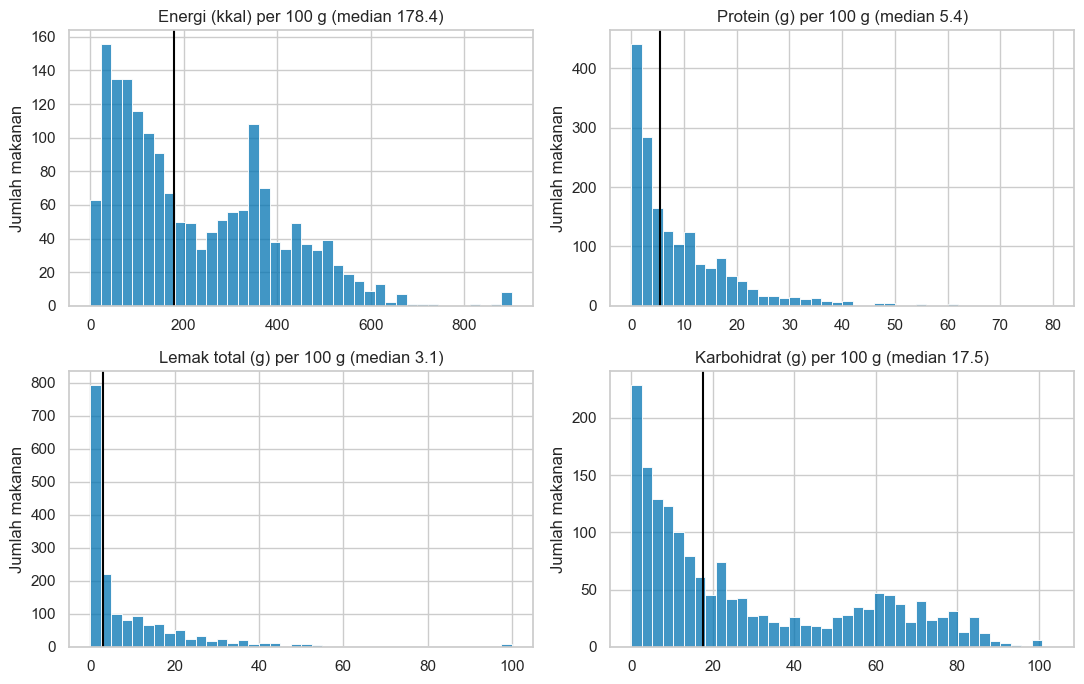

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, kolom in zip(axes.flat, ["energi_kkal_100g", "protein_g_100g", "lemak_total_g_100g", "karbohidrat_total_g_100g"]):
    median = df_bersih[kolom].median()
    sns.histplot(df_bersih[kolom], bins=40, ax=ax)
    ax.axvline(median, color="black")
    ax.set_title(f"{LABEL[kolom]} per 100 g (median {median:.1f})")
    ax.set_xlabel("")
    ax.set_ylabel("Jumlah makanan")
plt.tight_layout()
plt.show()

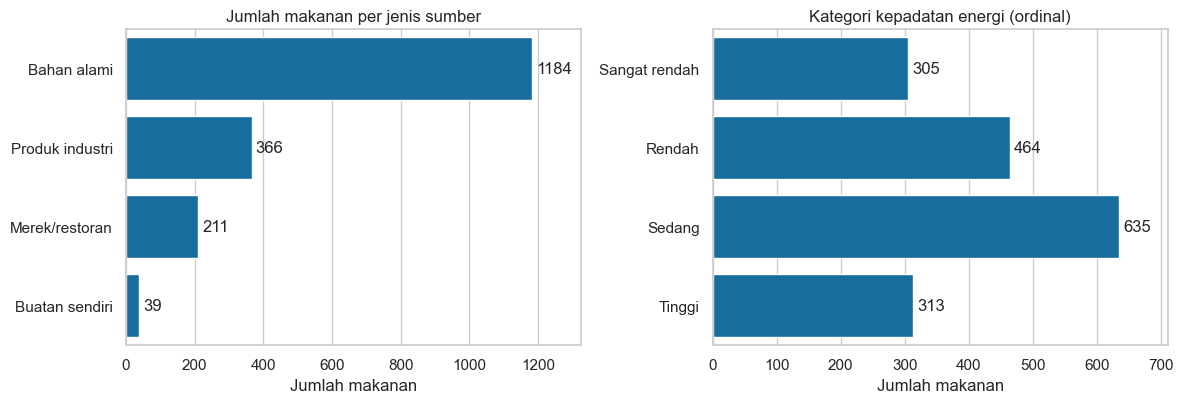

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.countplot(data=df_bersih, y="jenis_sumber", order=df_bersih["jenis_sumber"].value_counts().index, ax=axes[0])
sns.countplot(data=df_bersih, y="kategori_energi", order=URUTAN_ENERGI, ax=axes[1])
axes[0].set_title("Jumlah makanan per jenis sumber")
axes[1].set_title("Kategori kepadatan energi (ordinal)")
for ax in axes:
    ax.bar_label(ax.containers[0], padding=3)
    ax.margins(x=0.12)
    ax.set_xlabel("Jumlah makanan")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

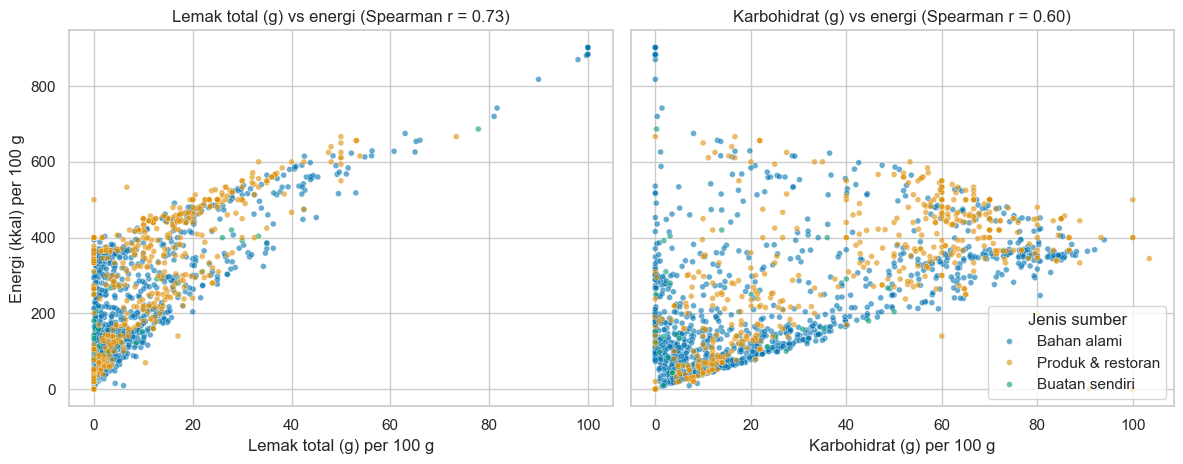

In [21]:
# produk industri dan merek/restoran digabung supaya warnanya tidak terlalu banyak
df_bersih["jenis_gabungan"] = df_bersih["jenis_sumber"].replace(
    {"Produk industri": "Produk & restoran", "Merek/restoran": "Produk & restoran"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for i, kolom in enumerate(["lemak_total_g_100g", "karbohidrat_total_g_100g"]):
    sns.scatterplot(data=df_bersih, x=kolom, y="energi_kkal_100g", hue="jenis_gabungan",
                    hue_order=["Bahan alami", "Produk & restoran", "Buatan sendiri"],
                    s=18, alpha=0.6, legend=False if i == 0 else "auto", ax=axes[i])
    r = df_bersih[[kolom, "energi_kkal_100g"]].corr(method="spearman").iloc[0, 1]
    axes[i].set_title(f"{LABEL[kolom]} vs energi (Spearman r = {r:.2f})")
    axes[i].set_xlabel(LABEL[kolom] + " per 100 g")
axes[0].set_ylabel("Energi (kkal) per 100 g")
sns.move_legend(axes[1], "lower right", title="Jenis sumber")
plt.tight_layout()
plt.show()

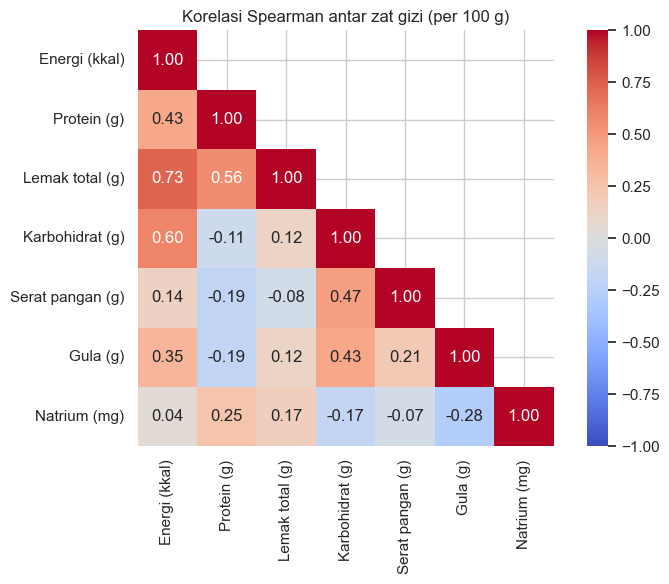

In [22]:
korelasi = df_bersih[KOLOM_100G].rename(columns=LABEL).corr(method="spearman")
segitiga_atas = np.triu(np.ones_like(korelasi, dtype=bool), k=1)  # isinya sama dengan segitiga bawah

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, mask=segitiga_atas, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Korelasi Spearman antar zat gizi (per 100 g)")
plt.tight_layout()
plt.show()

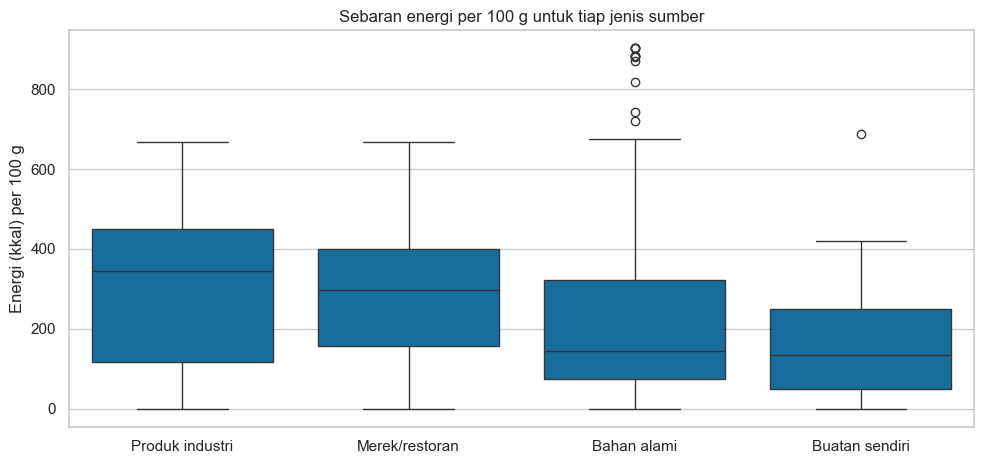

In [23]:
urutan = df_bersih.groupby("jenis_sumber")["energi_kkal_100g"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4.8))
sns.boxplot(data=df_bersih, x="jenis_sumber", y="energi_kkal_100g", order=urutan)
plt.title("Sebaran energi per 100 g untuk tiap jenis sumber")
plt.xlabel("")
plt.ylabel("Energi (kkal) per 100 g")
plt.tight_layout()
plt.show()

## 5. Ringkasan Laporan

Laporan analisis 1–2 halaman tersedia pada file PDF dengan nama yang sama. Poin utamanya:

1. **Deskripsi dataset** — 1.800 makanan dari nilaigizi.com (bahan alami TKPI 2018 serta produk kemasan/restoran),
   40 kolom: 5 nominal, 2 numerik diskrit, 33 numerik kontinu, ditambah 1 atribut ordinal turunan (`kategori_energi`).
2. **Statistik deskriptif** — seluruh zat gizi menceng ke kanan; median energi 178 kkal, protein 5,4 g, lemak 3,1 g,
   dan karbohidrat 17,5 g per 100 g. Data didominasi bahan alami (65,8%).
3. **Penanganan data** — nilai hilang dibedakan menjadi *tidak berlaku*, *benar-benar hilang*, dan *terselubung*
   (natrium 0 mg pada 84–89% produk). Nilai mustahil (takaran 0, energi 6.000 kkal/100 g) dijadikan NaN, 11 kolom yang
   hampir kosong dihapus, dan outlier alami (minyak, terasi) dipertahankan.
4. **Visualisasi & insight** — energi bersifat bimodal; lemak adalah penentu energi terkuat (r = 0,73); produk industri
   dan restoran rata-rata dua kali lebih padat energi dibanding bahan alami; natrium tidak berhubungan dengan zat makro.

**Keterbatasan:** konversi minuman memakai asumsi 1 ml ≈ 1 g, `jenis_sumber` diklasifikasikan dari pola nama produsen
(PT/CV/Tbk), dan data produk yang diambil hanya ID 1–1.850 dari sekitar 8.000 item di situs.